In [55]:
import pandas as pd

df = pd.read_csv("../../Data/Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [57]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [58]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [59]:
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [60]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [61]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["SpeciesEncoded"] = le.fit_transform(df["Species"])

In [62]:
# Fitur untuk clustering
X = df.drop(["Id", "Species", "SpeciesEncoded"], axis=1)
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


(array([49.,  8., 41., 29., 23.]),
 array([0.1 , 0.58, 1.06, 1.54, 2.02, 2.5 ]),
 <BarContainer object of 5 artists>)

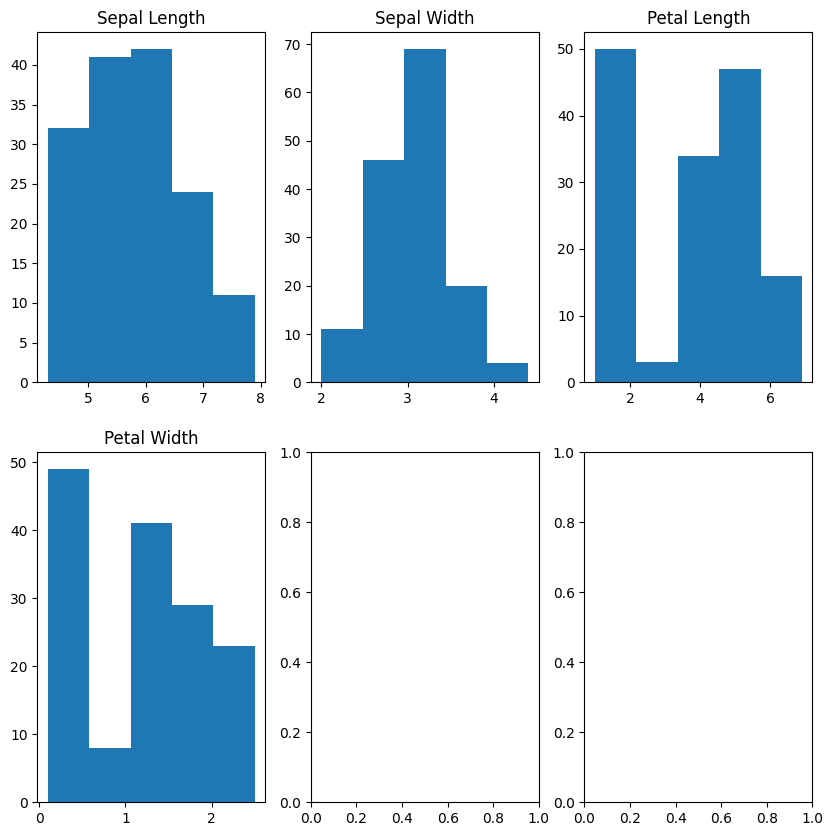

In [63]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots (nrows=2, ncols=3, figsize=(10, 10))

# Histogram 1: Sepal Length
axes[0, 0].set_title("Sepal Length")
axes[0, 0].hist(X["SepalLengthCm"], bins=5)

# Histogram 2: Sepal Width
axes[0, 1].set_title("Sepal Width")
axes[0, 1].hist(X["SepalWidthCm"], bins=5)

# Histogram 3: Petal Length
axes[0, 2].set_title("Petal Length")
axes[0, 2].hist(X["PetalLengthCm"], bins=5)

# Histogram 4: Petal Width
axes[1, 0].set_title("Petal Width")
axes[1, 0].hist(X["PetalWidthCm"], bins=5)

In [64]:
# Standar Scaller
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]

X = scaler.fit_transform(X)
X

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

#### Menentukan jumlah cluster

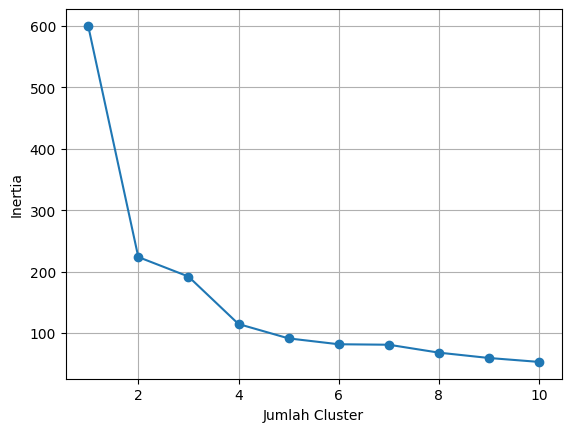

In [65]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_list = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia_list.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia_list, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [66]:

# Membangun model K-Means
kmeans = KMeans(n_clusters=3, # Dataset ada 3
                init='k-means++',
                random_state=42
                )
# dri slide
df["Cluster"] = kmeans.fit_predict(X)
print("Cluster ditemukan: ", df["Cluster"].unique())


Cluster ditemukan:  [1 2 0]


In [67]:
# Latih model K-Means
kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [68]:
labels = kmeans.predict(X)

In [69]:
df["Cluster"] = labels

In [70]:
print("Cluster ditemukan: ", df["Cluster"].unique())

Cluster ditemukan:  [1 2 0]


In [71]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X, df["Cluster"])
print("Silhouette Score: ", sil_score)

Silhouette Score:  0.4787241921049546


In [72]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:\n")
cm = confusion_matrix(df["SpeciesEncoded"], df["Cluster"])
cm

Confusion Matrix:



array([[ 0, 32, 18],
       [46,  0,  4],
       [50,  0,  0]])

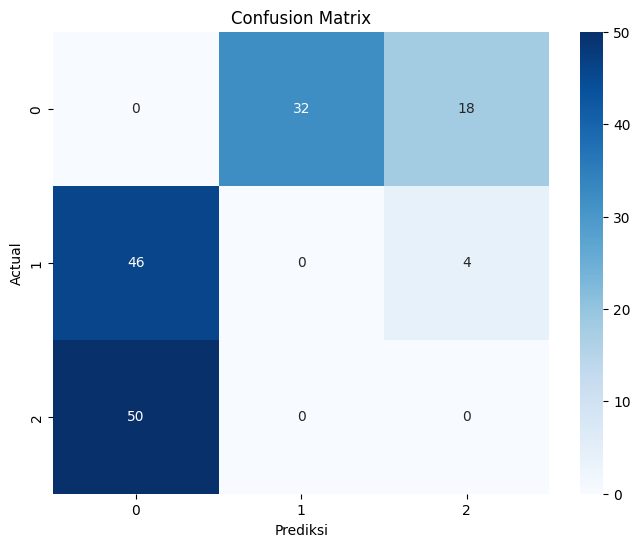

In [73]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediksi")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### 2D dan 3D Scatter Plot

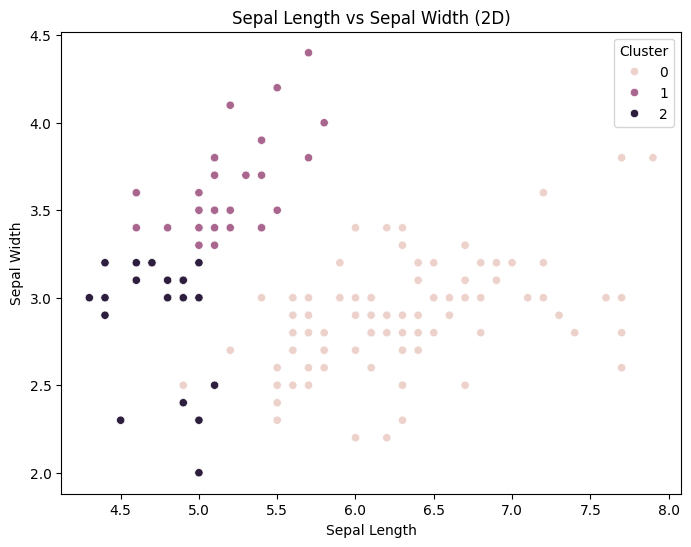

In [74]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="SepalLengthCm", y="SepalWidthCm", hue="Cluster", data=df)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Sepal Length vs Sepal Width (2D)")
plt.show()

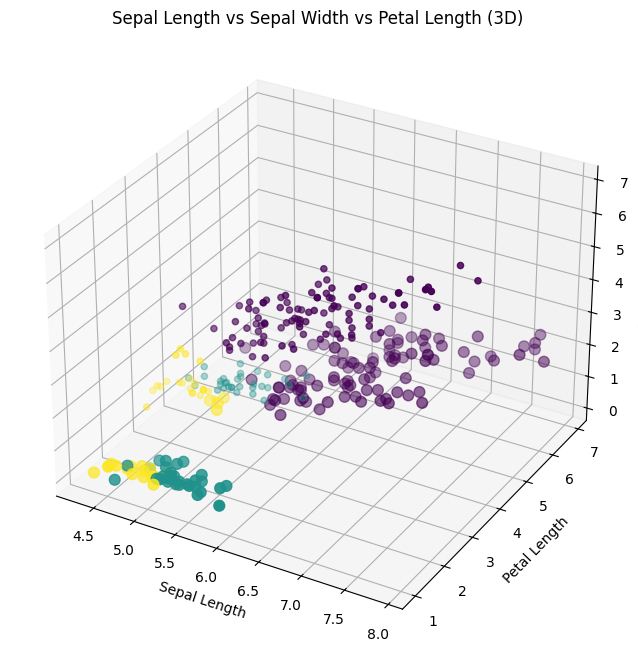

In [75]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['SepalLengthCm'], df['PetalLengthCm'], df['PetalWidthCm'], c=df['Cluster'], s=60)

ax.scatter(df['SepalLengthCm'], df['SepalWidthCm'], df['PetalLengthCm'], c=df['Cluster'], cmap='viridis')
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Petal Length')
ax.set_zlabel('Petal Width')
ax.set_title('Sepal Length vs Sepal Width vs Petal Length (3D)')
plt.show()

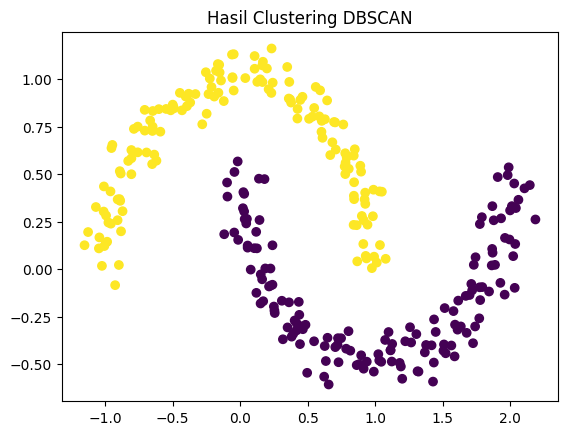

Label cluster yang ditemukan: {np.int64(0), np.int64(1)}


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# 1. Buat dataset contoh (bentuk seperti dua bulan sabit)
X, y = make_moons(n_samples=300, noise=0.07, random_state=42)

# 2. DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# 3. Visualisasi hasil klaster
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.title("Hasil Clustering DBSCAN")
plt.show()

print("Label cluster yang ditemukan:", set(labels))
